In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

USERNAME = "shreya"  # <- change to her username
BASE_PATH = f"/Users/{USERNAME}/Desktop/ARIA/data"

df = pd.read_csv(f"{BASE_PATH}/saas_churn.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBillin

In [3]:
print("Churn distribution:")
print(df['Churn'].value_counts())
print("\nPercentages:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


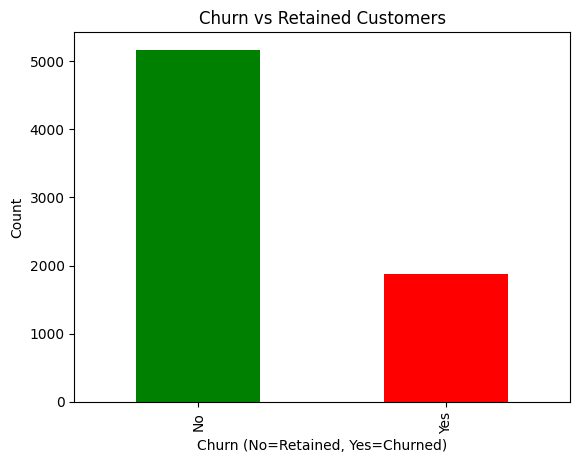

In [4]:
df['Churn'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Churn vs Retained Customers')
plt.xlabel('Churn (No=Retained, Yes=Churned)')
plt.ylabel('Count')
plt.show()

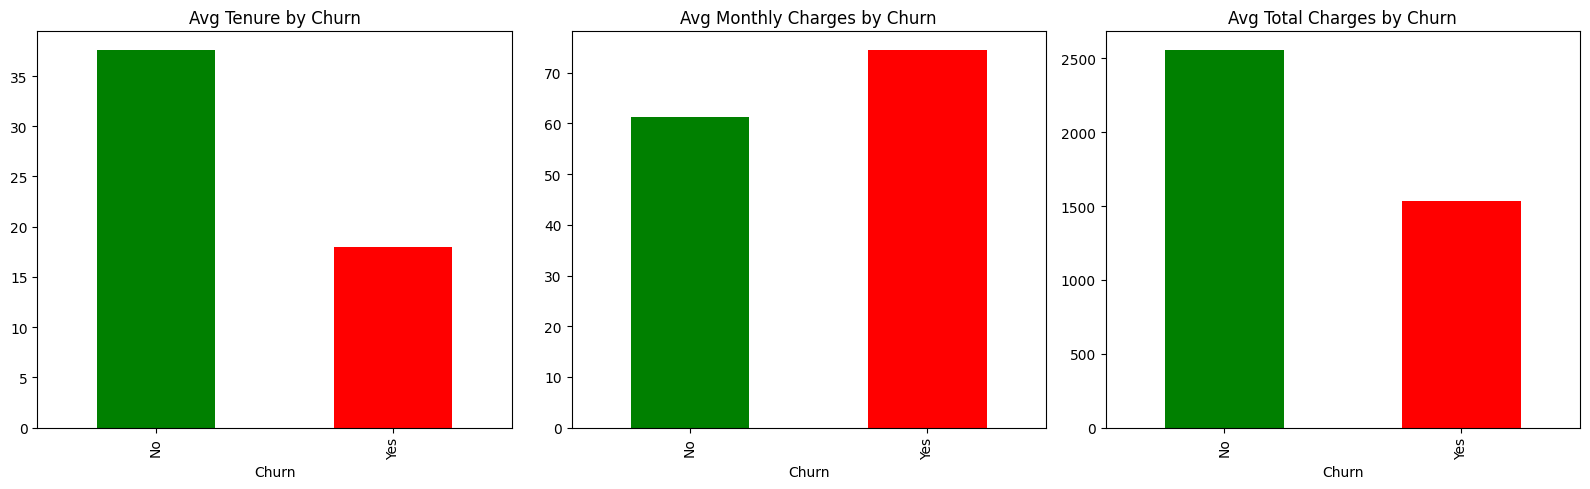

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

# Tenure
df.groupby('Churn')['tenure'].mean().plot(kind='bar', ax=axes[0], color=['green','red'])
axes[0].set_title('Avg Tenure by Churn')

# Monthly Charges
df.groupby('Churn')['MonthlyCharges'].mean().plot(kind='bar', ax=axes[1], color=['green','red'])
axes[1].set_title('Avg Monthly Charges by Churn')

# Total Charges - convert to numeric first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.groupby('Churn')['TotalCharges'].mean().plot(kind='bar', ax=axes[2], color=['green','red'])
axes[2].set_title('Avg Total Charges by Churn')

plt.tight_layout()
plt.show()

In [6]:
df.to_csv(f"{BASE_PATH}/saas_clean.csv", index=False)
print("✅ SaaS clean file saved")
print("Shape:", df.shape)

✅ SaaS clean file saved
Shape: (7043, 21)
